# DSP Signal Visualization

Loads the newest `debug_<TIMESTAMP>.csv` from the `data/` dir and plots the raw and filtered acceleration magnitudes from the digital signal processing thread when running `tools/debug_stream.py`. 

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from dataclasses import dataclass

REPO_ROOT = Path.cwd().resolve().parents[1]
DATA_DIR = REPO_ROOT / "data"
OPTIONAL_DATA_FILEPATH = None

## 1. Load data

In [2]:
candidates = sorted(DATA_DIR.glob("debug_*.csv"), key=lambda p: p.stat().st_mtime)
if not candidates:
    raise FileNotFoundError(f"no debug_*.csv under {DATA_DIR}")

csv_path = OPTIONAL_DATA_FILEPATH if OPTIONAL_DATA_FILEPATH else candidates[-1]
print(f"Using: {csv_path.name}")

df = pd.read_csv(csv_path)
df = df.sort_values(by="timestampUs")

# Remove the 0 timestamp row
df = df.iloc[1:]

# Time axis: seconds from first sample (microsecond timestamps from firmware)
t = (df["timestampUs"] - df["timestampUs"].iloc[0]) * 1e-6

df.head()

Using: debug_20260430_153205.csv


,timestampUs,ax,ay,az,mag,slope
1,189699560,0.001987,-0.000065,0.000030,0.002662,-0.000212
2,189709540,0.002282,0.000647,-0.001036,0.002645,-0.000018
3,189718542,0.000318,-0.000319,0.000415,0.002159,-0.000486
4,189728552,-0.001467,-0.001493,-0.001254,0.002226,0.000067
5,189738532,-0.000357,-0.000382,0.002926,0.002405,0.000179


## 2. Time series: accelerations (ax, ay, az)

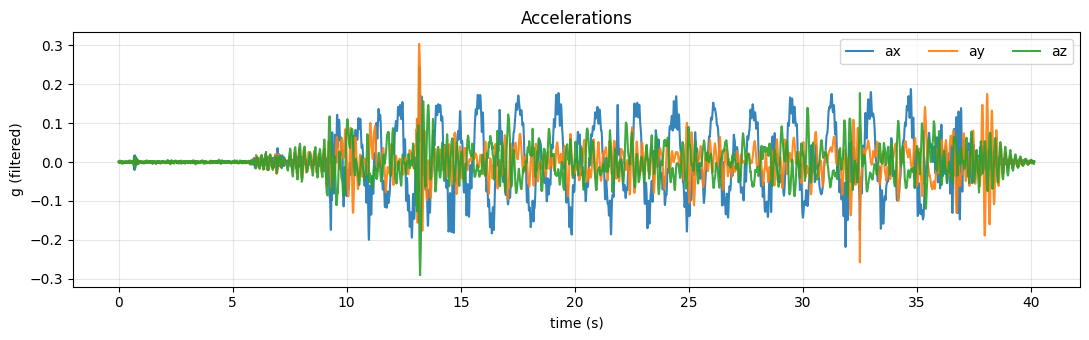

In [3]:
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, df["ax"], label="ax", alpha=0.9)
ax.plot(t, df["ay"], label="ay", alpha=0.9)
ax.plot(t, df["az"], label="az", alpha=0.9)
ax.set_xlabel("time (s)")
ax.set_ylabel("g (filtered)")
ax.set_title("Accelerations")
ax.legend(loc="upper right", ncol=3)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 3. Magnitude and slope

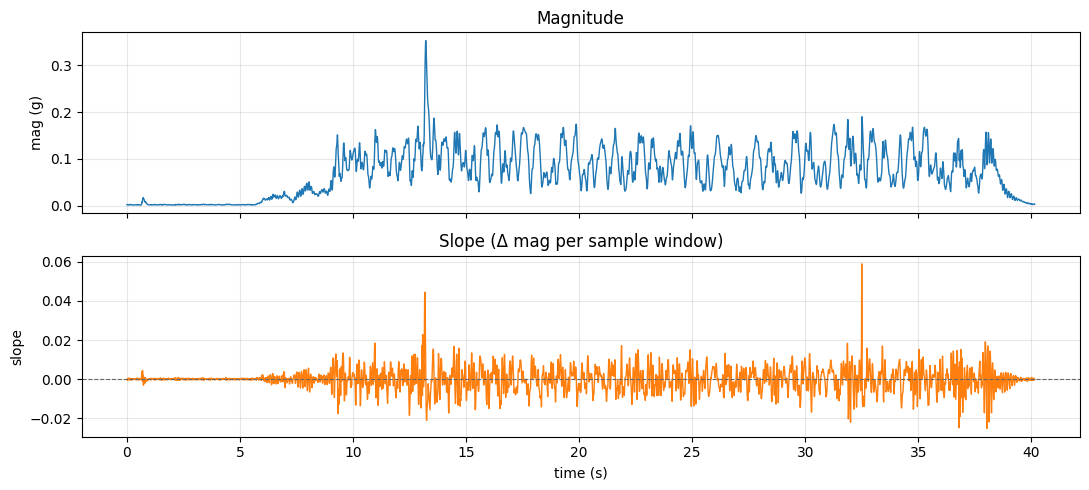

In [4]:
fig, (a0, a1) = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
a0.plot(t, df["mag"], color="C0", lw=1.0)
a0.set_ylabel("mag (g)")
a0.set_title("Magnitude")
a0.grid(True, alpha=0.3)

a1.plot(t, df["slope"], color="C1", lw=1.0)
a1.set_xlabel("time (s)")
a1.set_ylabel("slope")
a1.set_title("Slope (Δ mag per sample window)")
a1.axhline(0, color="0.4", ls="--", lw=0.8)
a1.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Step Detection


In [5]:
@dataclass
class StepDetectionConfig:
    ema_alpha: float = 0.02
    mag_scale: float = 4.35
    peak_threshold: float = 0.22
    min_step_dt: float = 0.18
    quiet_pre_n: int = 8
    quiet_abs: float = 0.044
    setdown_idle_s: float = 2.5
    peak_consistency_ratio: float = 0.6
    
class StepDetector:
    def __init__(self, config):
        self.cfg = config

    def _update_ema(self, x, baseline):
        a = self.cfg.ema_alpha
        baseline = a * x + (1.0 - a) * baseline
        return baseline

    def _is_local_peak(self, x_prev, x_prev2, x_next):
        return x_prev > x_prev2 and x_prev > x_next

    def _is_valid_peak(self, x_prev):
        return abs(x_prev) >= self.cfg.peak_threshold

    def _is_idle(self, dt):
        return dt > self.cfg.setdown_idle_s

    def _passes_refractory(self, dt):
        return dt >= self.cfg.min_step_dt

    def _passes_quiet_gate(self, x_detrended, i, dt, accepted_any):
        if not accepted_any:
            return True
        if not self._is_idle(dt):
            return True

        j0 = max(0, i - self.cfg.quiet_pre_n - 1)
        pre = x_detrended[j0:i - 1]

        if pre.size < 3:
            return True

        return float(np.mean(np.abs(pre))) >= self.cfg.quiet_abs

    def _passes_shoulder_filter(self, prev_peak_value, xd_im1, dt):
        if not self._is_idle(dt):
            return True
        if prev_peak_value <= 0:
            return True

        return abs(xd_im1) >= self.cfg.peak_consistency_ratio * prev_peak_value

    def _accept_peak(
        self,
        dt,
        x_detrended,
        i,
        accepted_any,
        prev_peak_value,
        xd_im1,
    ):
        return (
            self._passes_refractory(dt)
            and self._passes_quiet_gate(x_detrended, i, dt, accepted_any)
            and self._passes_shoulder_filter(prev_peak_value, xd_im1, dt)
        )

    def detect_steps_streaming(self, df):
        cfg = self.cfg

        mag = df["mag"].to_numpy(dtype=np.float64, copy=False)
        ts = df["timestampUs"].to_numpy(dtype=np.float64, copy=False)

        t = (ts - ts[0]) * 1e-6
        n = len(mag)

        if n == 0:
            empty = np.array([], dtype=np.float64)
            return [], [], empty, empty, np.array([], dtype=np.int8)

        x_detrended = np.zeros(n, dtype=np.float64)
        baseline_arr = np.zeros(n, dtype=np.float64)
        state_seq = np.zeros(n, dtype=np.int8)

        step_indices = []
        step_times = []

        baseline = float(mag[0]) * cfg.mag_scale

        last_step_t = -1e30
        accepted_any = False
        prev_peak_value = 0.0

        for i in range(n):
            x = float(mag[i]) * cfg.mag_scale

            baseline = self._update_ema(x, baseline)
            x_d = x - baseline

            x_detrended[i] = x_d
            baseline_arr[i] = baseline
            state_seq[i] = 0

            if i < 2:
                continue

            xd_im1 = x_detrended[i - 1]
            xd_i2 = x_detrended[i - 2]
            xd_i = x_d

            if not self._is_local_peak(xd_im1, xd_i2, xd_i):
                continue

            if not self._is_valid_peak(xd_im1):
                continue

            peak_idx = i - 1
            t_peak = float(t[peak_idx])

            dt = t_peak - last_step_t

            if not self._accept_peak(
                dt,
                x_detrended,
                i,
                accepted_any,
                prev_peak_value,
                xd_im1,
            ):
                continue

            step_indices.append(peak_idx)
            step_times.append(t_peak)

            last_step_t = t_peak
            accepted_any = True
            prev_peak_value = abs(xd_im1)

            state_seq[peak_idx] = 1

        return step_indices, step_times, x_detrended, baseline_arr, state_seq

In [6]:
cfg = StepDetectionConfig(
    ema_alpha=0.02, 
    mag_scale=4.35, 
    peak_threshold=0.22, 
    min_step_dt=0.18, 
    quiet_pre_n=8, 
    quiet_abs=0.044, 
    setdown_idle_s=2.5,
    peak_consistency_ratio=0.6
)

sd = StepDetector(cfg)

out = sd.detect_steps_streaming(df)
(
    step_indices,
    step_times,
    x_detrended,
    baseline_arr,
    state_seq,
) = out

print(f"Detected steps: {len(step_indices)}")


Detected steps: 32


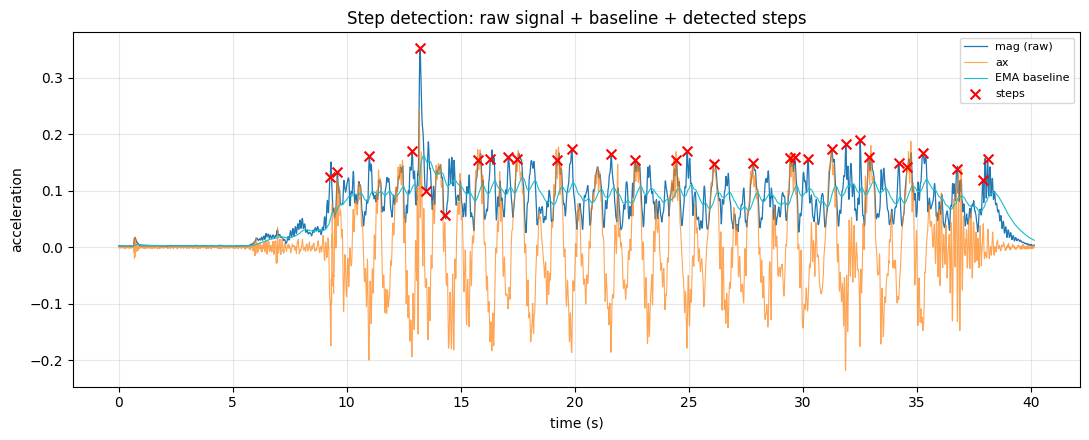

In [7]:
t_np = np.asarray(t, dtype=float)
mag_np = np.asarray(df["mag"], dtype=float)
ax_np = np.asarray(df["ax"], dtype=float)

fig, ax0 = plt.subplots(figsize=(11, 4.5))

ax0.plot(t_np, mag_np, label="mag (raw)", color="tab:blue", lw=0.9)
ax0.plot(t_np, ax_np, label="ax", color="tab:orange", alpha=0.7, lw=0.8)

ax0.plot(
    t_np,
    baseline_arr / cfg.mag_scale,
    label="EMA baseline",
    color="tab:cyan",
    lw=0.8,
)

if len(step_indices):
    ax0.scatter(
        t_np[step_indices],
        mag_np[step_indices],
        color="red",
        s=50,
        marker="x",
        zorder=5,
        label="steps",
    )

ax0.set_xlabel("time (s)")
ax0.set_ylabel("acceleration")
ax0.set_title("Step detection: raw signal + baseline + detected steps")
ax0.grid(True, alpha=0.3)
ax0.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()